# Fase 5 — Evaluación

Evaluación final en **test** (RF, SVM, CNN, baseline), análisis de errores e investigación de la **fuga por casi-duplicados** (split consciente de grupos, re-evaluación ML).

> Conclusiones en `reports/05_evaluacion.md`. La re-evaluación de la CNN con split por grupos está en `notebooks/05_cnn_grupos.ipynb`.

## 0. Configuración y carga de modelos

In [1]:
import sys, time, json
from pathlib import Path
root = Path.cwd()
while not (root / 'src').exists() and root != root.parent:
    root = root.parent
sys.path.insert(0, str(root))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import joblib
import tensorflow as tf
from sklearn.metrics import classification_report

from src.data.dataset import build_index, QUALITY_ORDER
from src.data import preprocess as pp, dedup
from src.evaluation.metrics import evaluate, plot_confusion, summary_row

sns.set_theme(style='whitegrid')
ART = root / 'artifacts'
df = pp.make_splits(pp.clean_index(build_index()))
d = np.load(ART/'features.npz', allow_pickle=True)
Xtr,ytr,Xva,yva,Xte,yte = d['Xtr'],d['ytr'],d['Xva'],d['yva'],d['Xte'],d['yte']
rf = joblib.load(ART/'rf.pkl'); svm = joblib.load(ART/'svm.pkl')
cnn = tf.keras.models.load_model(ART/'cnn.keras')
print('Modelos y features cargados. Test:', Xte.shape)

Modelos y features cargados. Test: (1171, 1860)


## 1. Evaluación final en TEST

In [2]:
base_pred = np.full(len(yte), 'Regular')           # clase mayoritaria
rf_pred = rf.predict(Xte)
svm_pred = svm.predict(Xte)

Xte_img, yte_img = pp.load_images_uint8(df[df.split=='test'], verbose=False)
cnn_proba = cnn.predict(Xte_img, batch_size=32, verbose=0)
cnn_pred = np.array([QUALITY_ORDER[i] for i in cnn_proba.argmax(1)])
assert list(yte_img) == list(yte), 'orden de etiquetas inconsistente'

rows = [summary_row('Baseline (mayoría)', yte, base_pred),
        summary_row('CNN (desde cero)', yte, cnn_pred),
        summary_row('Random Forest', yte, rf_pred),
        summary_row('SVM (RBF)', yte, svm_pred)]
comp = pd.DataFrame(rows).set_index('modelo').sort_values('macro_f1')
display(comp)

,macro_f1,balanced_acc,recall_Bad
modelo,,,
Baseline (mayoría),0.2012,0.3333,0.0000
CNN (desde cero),0.9345,0.9317,0.8571
Random Forest,0.9411,0.9294,0.8008
SVM (RBF),0.9570,0.9535,0.9023


## 2. Comparación de Macro-F1 en test

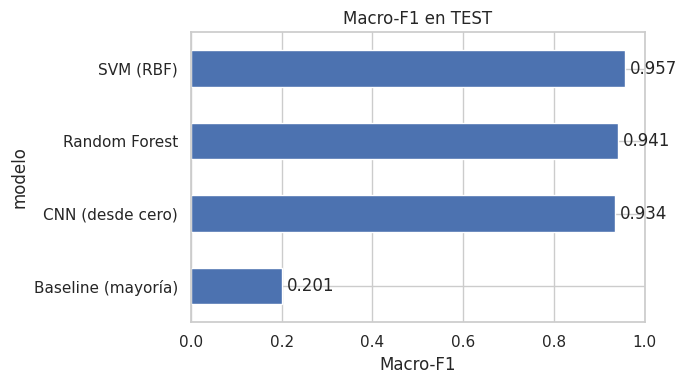

In [3]:
fig, ax = plt.subplots(figsize=(7,4))
comp['macro_f1'].plot(kind='barh', ax=ax, color='#4c72b0')
ax.set_title('Macro-F1 en TEST'); ax.set_xlabel('Macro-F1'); ax.set_xlim(0,1)
for i,v in enumerate(comp['macro_f1']): ax.text(v+0.01,i,f'{v:.3f}',va='center')
plt.tight_layout(); plt.show()

## 3. Matrices de confusión en test (RF, SVM, CNN)

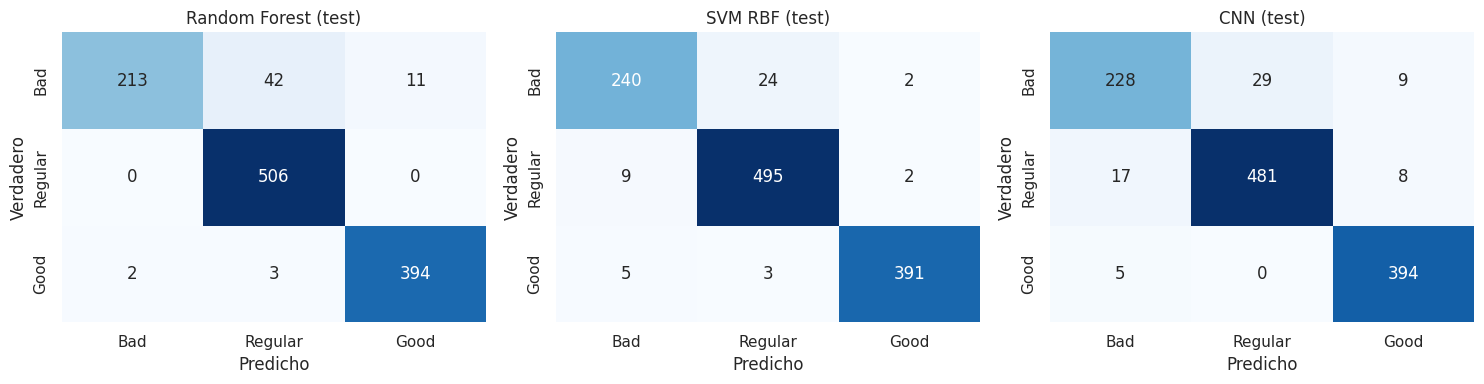

In [4]:
fig, axes = plt.subplots(1,3, figsize=(15,4))
plot_confusion(yte, rf_pred, axes[0], 'Random Forest (test)')
plot_confusion(yte, svm_pred, axes[1], 'SVM RBF (test)')
plot_confusion(yte, cnn_pred, axes[2], 'CNN (test)')
plt.tight_layout(); plt.show()

## 4. Reporte por clase del mejor modelo en test

In [5]:
best = comp['macro_f1'].idxmax()
preds = {'Random Forest':rf_pred,'SVM (RBF)':svm_pred,'CNN (desde cero)':cnn_pred}
bp = preds[best]
print('Mejor modelo en test:', best)
print(classification_report(yte, bp, labels=QUALITY_ORDER, zero_division=0))

Mejor modelo en test: SVM (RBF)
              precision    recall  f1-score   support

         Bad       0.94      0.90      0.92       266
     Regular       0.95      0.98      0.96       506
        Good       0.99      0.98      0.98       399

    accuracy                           0.96      1171
   macro avg       0.96      0.95      0.96      1171
weighted avg       0.96      0.96      0.96      1171



## 5. Análisis de errores: el error más costoso (Bad → Good)

Casos Bad->Good: 2


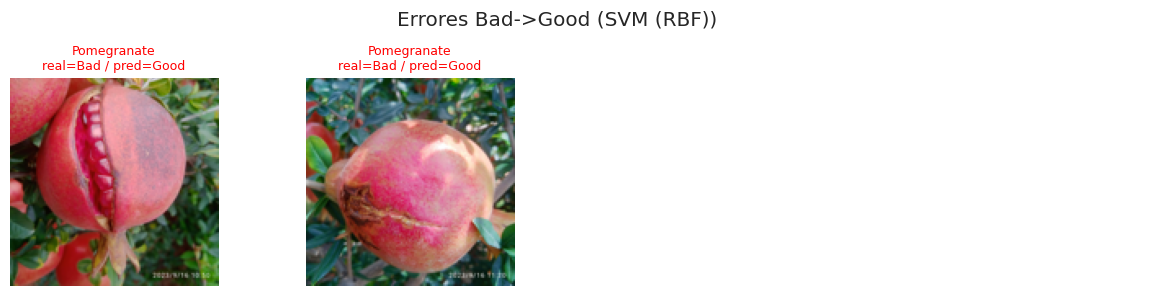

In [6]:
test_df = df[df.split=='test'].reset_index(drop=True).copy()
test_df['pred'] = bp
bad_as_good = test_df[(test_df['quality']=='Bad') & (test_df['pred']=='Good')]
print(f'Casos Bad->Good: {len(bad_as_good)}')
n = min(8, len(bad_as_good))
if n>0:
    sample = bad_as_good.sample(n, random_state=42)
    cols=4; rows=(n+cols-1)//cols
    fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 3*rows))
    axarr = np.array(axes).ravel()
    for ax,(_,r) in zip(axarr, sample.iterrows()):
        ax.imshow(pp.load_rgb(r['path'], size=(128,128))); ax.axis('off')
        ax.set_title(f"{r['fruit']}\nreal=Bad / pred=Good", fontsize=9, color='red')
    for ax in axarr[n:]: ax.axis('off')
    plt.suptitle(f'Errores Bad->Good ({best})'); plt.tight_layout(); plt.show()
else:
    print('No hay casos Bad->Good con este modelo.')

## 6. Fuga por casi-duplicados: detección de grupos

Imágenes: 7803 | Grupos (ejemplares únicos aprox.): 6884
Casi-duplicados: 11.8% de las imágenes
Clúster más grande: 15 imágenes | dHash-256, umbral 10 | 0s


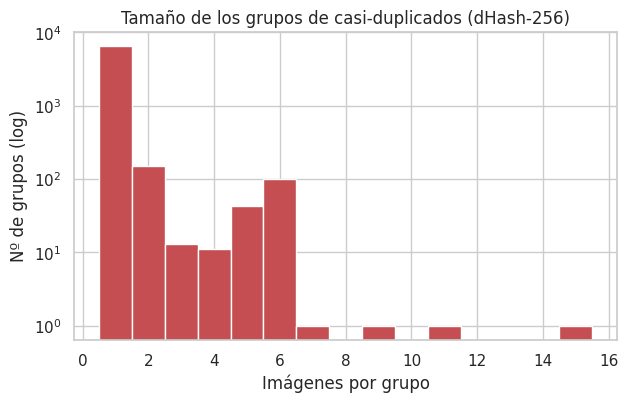

In [7]:
t0=time.time()
bits = dedup.compute_hash_bits(df, cache_path=ART/'dhash.npz', verbose=True)
df['group'] = dedup.assign_groups(bits, threshold=dedup.GROUP_THRESHOLD)
n_imgs=len(df); n_groups=df['group'].nunique()
sizes = df['group'].value_counts()
print(f'Imágenes: {n_imgs} | Grupos (ejemplares únicos aprox.): {n_groups}')
print(f'Casi-duplicados: {100*(1-n_groups/n_imgs):.1f}% de las imágenes')
print(f'Clúster más grande: {sizes.max()} imágenes | dHash-256, umbral {dedup.GROUP_THRESHOLD} | {time.time()-t0:.0f}s')

fig, ax = plt.subplots(figsize=(7,4))
ax.hist(sizes.values, bins=range(1, sizes.max()+2), color='#c44e52', align='left')
ax.set_yscale('log'); ax.set_title('Tamaño de los grupos de casi-duplicados (dHash-256)')
ax.set_xlabel('Imágenes por grupo'); ax.set_ylabel('Nº de grupos (log)')
plt.show()

## 7. Cuantificación de la fuga en el split aleatorio original

In [8]:
groups_train = set(df[df.split=='train']['group'])
test_o = df[df.split=='test']
leaked = test_o[test_o['group'].isin(groups_train)]
pct = 100*len(leaked)/len(test_o)
print(f'Imágenes de test con casi-duplicado en train: {len(leaked)}/{len(test_o)} ({pct:.1f}%)')
val_o = df[df.split=='val']
leaked_v = val_o[val_o['group'].isin(groups_train)]
print(f'Idem en validación: {len(leaked_v)}/{len(val_o)} ({100*len(leaked_v)/len(val_o):.1f}%)')

Imágenes de test con casi-duplicado en train: 176/1171 (15.0%)
Idem en validación: 166/1171 (14.2%)


## 8. Split consciente de grupos y re-evaluación de los modelos ML

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

X_all = np.zeros((len(df), Xtr.shape[1]), dtype=np.float32)
y_all = np.empty(len(df), dtype=object)
for sp,(Xs,ys) in {'train':(Xtr,ytr),'val':(Xva,yva),'test':(Xte,yte)}.items():
    m=(df['split']==sp).to_numpy(); X_all[m]=Xs; y_all[m]=ys

dfg = dedup.make_group_splits(df)
df['gsplit']=dfg['gsplit'].values
gtr=(df['gsplit']=='train').to_numpy(); gte=(df['gsplit']=='test').to_numpy()
print('Group-split:', df['gsplit'].value_counts().to_dict())

rf_g = RandomForestClassifier(n_estimators=400, min_samples_leaf=1, class_weight='balanced', random_state=42, n_jobs=-1).fit(X_all[gtr], y_all[gtr])
svm_g = Pipeline([('s',StandardScaler()),('svc',SVC(kernel='rbf',C=10,gamma='scale',class_weight='balanced',random_state=42))]).fit(X_all[gtr], y_all[gtr])
rf_gp = rf_g.predict(X_all[gte]); svm_gp = svm_g.predict(X_all[gte])

comp_g = pd.DataFrame([
    summary_row('RF — split aleatorio (test)', yte, rf_pred),
    summary_row('RF — split por grupos', y_all[gte], rf_gp),
    summary_row('SVM — split aleatorio (test)', yte, svm_pred),
    summary_row('SVM — split por grupos', y_all[gte], svm_gp),
]).set_index('modelo')
display(comp_g)

df[['path','quality','group','gsplit']].to_csv(ART/'group_split.csv', index=False)
print('group_split.csv guardado para la CNN.')

Group-split: {'train': 5436, 'val': 1221, 'test': 1146}


,macro_f1,balanced_acc,recall_Bad
modelo,,,
RF — split aleatorio (test),0.9411,0.9294,0.8008
RF — split por grupos,0.9460,0.9382,0.8262
SVM — split aleatorio (test),0.9570,0.9535,0.9023
SVM — split por grupos,0.9639,0.9618,0.9149


group_split.csv guardado para la CNN.


## 9. Comparación visual: split aleatorio vs. por grupos (ML)

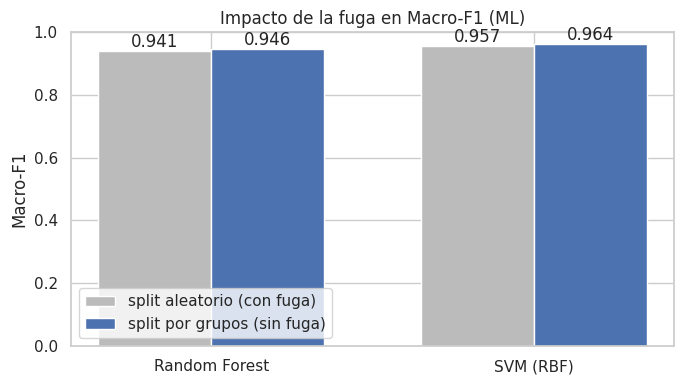

In [10]:
rand=[comp.loc['Random Forest','macro_f1'], comp.loc['SVM (RBF)','macro_f1']]
grp=[summary_row('',y_all[gte],rf_gp)['macro_f1'], summary_row('',y_all[gte],svm_gp)['macro_f1']]
labels=['Random Forest','SVM (RBF)']; x=np.arange(2); w=0.35
fig,ax=plt.subplots(figsize=(7,4))
b1=ax.bar(x-w/2, rand, w, label='split aleatorio (con fuga)', color='#bbbbbb')
b2=ax.bar(x+w/2, grp, w, label='split por grupos (sin fuga)', color='#4c72b0')
ax.bar_label(b1, fmt='%.3f'); ax.bar_label(b2, fmt='%.3f')
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylim(0,1)
ax.set_ylabel('Macro-F1'); ax.set_title('Impacto de la fuga en Macro-F1 (ML)'); ax.legend()
plt.tight_layout(); plt.show()